In [11]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel
from astropy.coordinates import HeliocentricMeanEcliptic, ICRS, CartesianRepresentation
from astropy.coordinates import solar_system_ephemeris
import astropy.coordinates as coord
from astropy.utils.data import download_file


import spiceypy as spice
spice.furnsh("naif0012.tls")
spice.furnsh("2024_PDC25a-s3-merged-DE441.bsp")

from poliastro.bodies import Sun, Earth, Mars
from poliastro.iod import izzo

ids = spice.spkobj("2024_PDC25a-s3-merged-DE441.bsp")
print(list(ids))

naif_ID = ids[0]
print(naif_ID)
coverage = spice.spkcov("2024_PDC25a-s3-merged-DE441.bsp", naif_ID)
start, end = spice.wnfetd(coverage, 0)
print(spice.et2utc(start, "C", 0), "→", spice.et2utc(end, "C", 0))

[-937020, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 199, 299, 301, 399]
-937020
1997 DEC 31 23:58:57 → 2041 APR 24 16:24:52


In [2]:
launch_start  = Time("2028-09-01", scale="tdb")
launch_end    = Time("2029-04-01", scale="tdb")
arrival_start = Time("2029-03-01", scale="tdb")
arrival_end   = Time("2030-02-01", scale="tdb")

N_launch  = 60
N_arrival = 60

launch_dates  = launch_start  + (launch_end  - launch_start)  * np.linspace(0, 1, N_launch)
arrival_dates = arrival_start + (arrival_end - arrival_start) * np.linspace(0, 1, N_arrival)

print("launch_dates[0]: ",  launch_dates[0].iso)
print("launch_dates[-1]:", launch_dates[-1].iso)
print("arrival_dates[0]: ", arrival_dates[0].iso)
print("arrival_dates[-1]:", arrival_dates[-1].iso)

launch_dates[0]:  2028-09-01 00:00:00.000
launch_dates[-1]: 2029-04-01 00:00:00.000
arrival_dates[0]:  2029-03-01 00:00:00.000
arrival_dates[-1]: 2030-02-01 00:00:00.000


In [3]:
# And make sure your sweep uses the fixed functions:
mu_sun = Sun.k.to(u.km**3 / u.s**2)

OBLIQUITY = np.radians(23.439)
ROT = np.array([
    [1,              0,               0],
    [0,  np.cos(OBLIQUITY), np.sin(OBLIQUITY)],
    [0, -np.sin(OBLIQUITY), np.cos(OBLIQUITY)]
])

def get_body_state(body_name, time):
    r_body, v_body = get_body_barycentric_posvel(body_name, time)
    r_sun,  v_sun  = get_body_barycentric_posvel("sun", time)
    r_eq = (r_body.xyz - r_sun.xyz).to(u.km).value
    v_eq = (v_body.xyz - v_sun.xyz).to(u.km / u.s).value
    return (ROT @ r_eq) * u.km, (ROT @ v_eq) * (u.km / u.s)

C3       = np.full((N_launch, N_arrival), np.nan)
vinf_arr = np.full((N_launch, N_arrival), np.nan)
TOF      = np.full((N_launch, N_arrival), np.nan)

for i, t_launch in enumerate(launch_dates):
    r1, v1_earth = get_body_state("earth", t_launch)
    for j, t_arrival in enumerate(arrival_dates):
        if t_arrival <= t_launch:
            continue
        tof = (t_arrival - t_launch).to(u.s)
        r2, v2_mars = get_body_state("mars", t_arrival)
        try:
            v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof, M=0))
        except Exception:
            continue
        dv1 = v1_sc - v1_earth
        dv2 = v2_sc - v2_mars
        C3[i, j]       = float(np.linalg.norm(dv1.value)**2)
        vinf_arr[i, j] = float(np.linalg.norm(dv2.value))
        TOF[i, j]      = float(tof.to(u.day).value)

print(f"Valid cells : {np.sum(~np.isnan(C3))} / {N_launch * N_arrival}")
print(f"C3  min/max : {np.nanmin(C3):.1f} / {np.nanmax(C3):.1f} km²/s²")
print(f"TOF min/max : {np.nanmin(TOF):.0f} / {np.nanmax(TOF):.0f} days")

Valid cells : 3569 / 3600
C3  min/max : 9.0 / 15737258.8 km²/s²
TOF min/max : 1 / 518 days


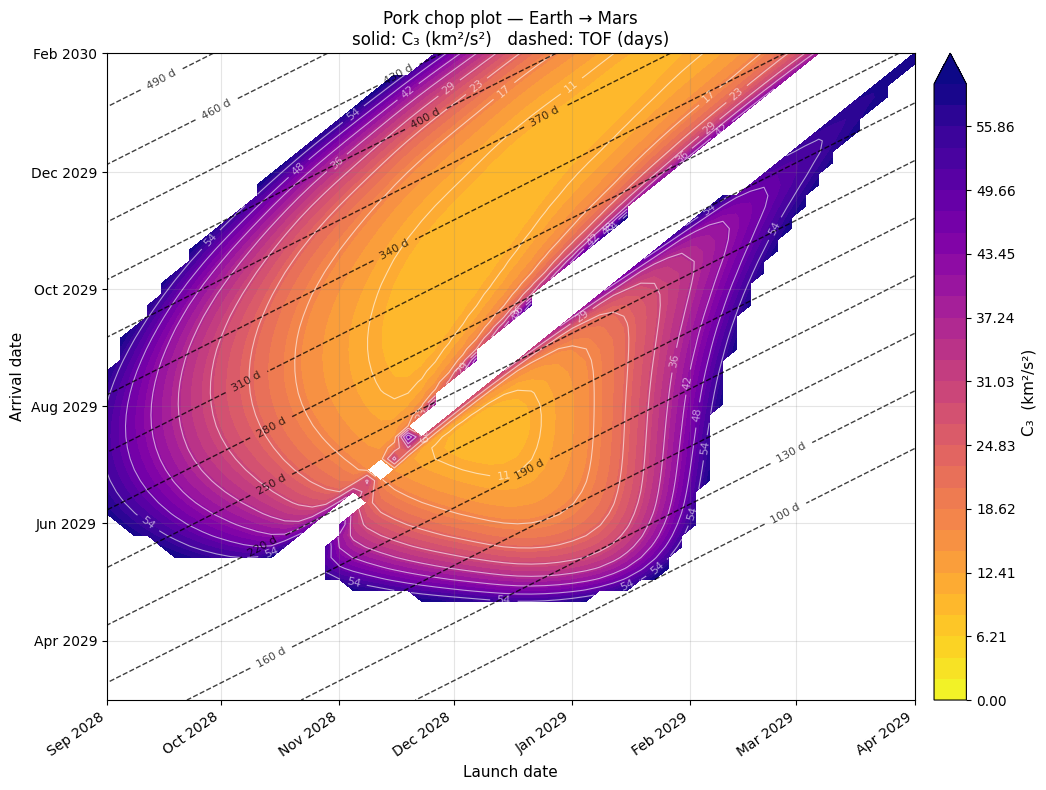

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
import numpy as np

# ── Clip C3 to a readable range ───────────────────────────────────────
C3_MAX = 60.0   # km²/s² — adjust if your min C3 is higher
C3_plot = np.where((C3 > C3_MAX) | np.isnan(C3), np.nan, C3)

# ── Build date axes ───────────────────────────────────────────────────
import matplotlib.dates as mdates
launch_dts  = [t.to_datetime() for t in launch_dates]
arrival_dts = [t.to_datetime() for t in arrival_dates]
L, A = np.meshgrid(mdates.date2num(launch_dts),
                   mdates.date2num(arrival_dts), indexing='ij')

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

# Filled C3 background
levels_fill = np.linspace(0, C3_MAX, 30)
cf = ax.contourf(L, A, C3_plot, levels=levels_fill,
                 cmap='plasma_r', extend='max')
cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('C₃  (km²/s²)', fontsize=11)

# Solid C3 contour lines + labels
c3_line_levels = np.linspace(5, C3_MAX, 10)
cs = ax.contour(L, A, C3_plot, levels=c3_line_levels,
                colors='white', linewidths=0.8, alpha=0.6)
ax.clabel(cs, fmt='%.0f', fontsize=8, inline=True)

# Dashed TOF contour lines + labels
tof_levels = np.arange(100, int(np.nanmax(TOF)) + 1, 30)
tof_cs = ax.contour(L, A, TOF, levels=tof_levels,
                    colors='black', linewidths=1.0,
                    linestyles='dashed', alpha=0.75)
ax.clabel(tof_cs, fmt='%d d', fontsize=8, inline=True)

# ── Format axes as calendar dates ─────────────────────────────────────
ax.xaxis_date()
ax.yaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.yaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=35)

ax.set_xlabel('Launch date', fontsize=11)
ax.set_ylabel('Arrival date', fontsize=11)
ax.set_title('Pork chop plot — Earth → Mars\n'
             'solid: C₃ (km²/s²)   dashed: TOF (days)',
             fontsize=12)
ax.grid(color='gray', alpha=0.2)

plt.tight_layout()
# plt.savefig('pork_chop.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
import spiceypy as spice
import numpy as np
from astropy import units as u
from astropy.time import Time

# ── Load kernels ───────────────────────────────────────────────────────
spice.furnsh("naif0012.tls")                   # leap second kernel
spice.furnsh("2024_PDC25a-s3-merged-DE441.bsp")      # your BSP

NAIF_SUN      = 10
NAIF_EARTH    = 399
NAIF_ASTEROID = -937020

OBLIQUITY = np.radians(23.439)
ROT = np.array([
    [1,              0,               0],
    [0,  np.cos(OBLIQUITY), np.sin(OBLIQUITY)],
    [0, -np.sin(OBLIQUITY), np.cos(OBLIQUITY)]
])

def get_state_from_bsp(naif_id, time):
    """Get heliocentric ecliptic state of a body from the BSP file.
    
    Returns r (km), v (km/s) as astropy Quantities in the ecliptic frame,
    consistent with what izzo.lambert expects.
    """
    et = spice.str2et(time.iso)  # convert astropy Time to SPICE ephemeris time
    
    # State relative to Sun, in J2000 equatorial frame
    state, _ = spice.spkez(naif_id, et, "J2000", "NONE", NAIF_SUN)
    
    r_eq = np.array(state[:3])  # km
    v_eq = np.array(state[3:])  # km/s
    
    # Rotate equatorial → ecliptic (same rotation we used before)
    r_ecl = ROT @ r_eq
    v_ecl = ROT @ v_eq
    
    return r_ecl * u.km, v_ecl * (u.km / u.s)

launch_start  = Time("2029-01-01", scale="tdb")
launch_end    = Time("2030-01-01", scale="tdb")
arrival_start = Time("2030-01-01", scale="tdb")
arrival_end   = Time("2031-01-01", scale="tdb")

N_launch  = 60
N_arrival = 60

launch_dates  = launch_start  + (launch_end  - launch_start)  * np.linspace(0, 1, N_launch)
arrival_dates = arrival_start + (arrival_end - arrival_start) * np.linspace(0, 1, N_arrival)

print("launch_dates[0]: ",  launch_dates[0].iso)
print("launch_dates[-1]:", launch_dates[-1].iso)
print("arrival_dates[0]: ", arrival_dates[0].iso)
print("arrival_dates[-1]:", arrival_dates[-1].iso)

# ── Verify the states look sane ────────────────────────────────────────
t_test = Time("2029-06-01", scale="tdb")

r_earth, v_earth = get_state_from_bsp(NAIF_EARTH, t_test)
r_ast,   v_ast   = get_state_from_bsp(NAIF_ASTEROID, t_test)

print(f"|r_earth|: {np.linalg.norm(r_earth.value):.4e} km  (expect ~1.5e8)")
print(f"|v_earth|: {np.linalg.norm(v_earth.value):.2f} km/s  (expect ~29.8)")
print(f"|r_ast|:   {np.linalg.norm(r_ast.value):.4e} km")
print(f"|v_ast|:   {np.linalg.norm(v_ast.value):.2f} km/s")

# ── Updated sweep loop ─────────────────────────────────────────────────
for i, t_launch in enumerate(launch_dates):
    r1, v1_earth = get_state_from_bsp(NAIF_EARTH, t_launch)

    for j, t_arrival in enumerate(arrival_dates):
        if t_arrival <= t_launch:
            continue

        tof = (t_arrival - t_launch).to(u.s)
        r2, v2_ast = get_state_from_bsp(NAIF_ASTEROID, t_arrival)

        try:
            v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof, M=0))
        except Exception:
            continue

        dv1 = v1_sc - v1_earth
        dv2 = v2_sc - v2_ast

        C3[i, j]       = float(np.linalg.norm(dv1.value)**2)
        vinf_arr[i, j] = float(np.linalg.norm(dv2.value))
        TOF[i, j]      = float(tof.to(u.day).value)

print(f"Valid cells : {np.sum(~np.isnan(C3))} / {N_launch * N_arrival}")
print(f"C3  min/max : {np.nanmin(C3):.1f} / {np.nanmax(C3):.1f} km²/s²")
print(f"TOF min/max : {np.nanmin(TOF):.0f} / {np.nanmax(TOF):.0f} days")

launch_dates[0]:  2029-01-01 00:00:00.000
launch_dates[-1]: 2030-01-01 00:00:00.000
arrival_dates[0]:  2030-01-01 00:00:00.000
arrival_dates[-1]: 2031-01-01 00:00:00.000
|r_earth|: 1.5169e+08 km  (expect ~1.5e8)
|v_earth|: 29.36 km/s  (expect ~29.8)
|r_ast|:   3.3051e+08 km
|v_ast|:   16.29 km/s
Valid cells : 3599 / 3600
C3  min/max : 9.0 / 748799.0 km²/s²
TOF min/max : 6 / 730 days


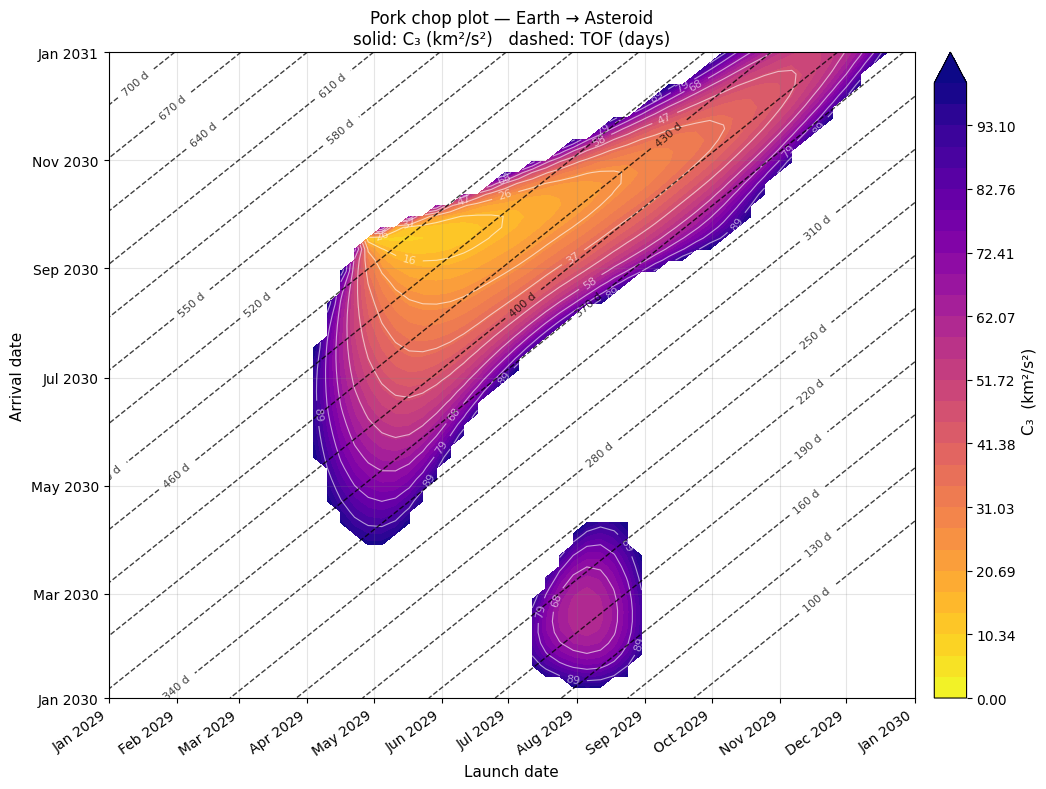

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
import numpy as np

# ── Clip C3 to a readable range ───────────────────────────────────────
C3_MAX = 100   # km²/s² — adjust if your min C3 is higher
C3_plot = np.where((C3 > C3_MAX) | np.isnan(C3), np.nan, C3)

# ── Build date axes ───────────────────────────────────────────────────
import matplotlib.dates as mdates
launch_dts  = [t.to_datetime() for t in launch_dates]
arrival_dts = [t.to_datetime() for t in arrival_dates]
L, A = np.meshgrid(mdates.date2num(launch_dts),
                   mdates.date2num(arrival_dts), indexing='ij')

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

# Filled C3 background
levels_fill = np.linspace(0, C3_MAX, 30)
cf = ax.contourf(L, A, C3_plot, levels=levels_fill,
                 cmap='plasma_r', extend='max')
cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('C₃  (km²/s²)', fontsize=11)

# Solid C3 contour lines + labels
c3_line_levels = np.linspace(5, C3_MAX, 10)
cs = ax.contour(L, A, C3_plot, levels=c3_line_levels,
                colors='white', linewidths=0.8, alpha=0.6)
ax.clabel(cs, fmt='%.0f', fontsize=8, inline=True)

# Dashed TOF contour lines + labels
tof_levels = np.arange(100, int(np.nanmax(TOF)) + 1, 30)
tof_cs = ax.contour(L, A, TOF, levels=tof_levels,
                    colors='black', linewidths=1.0,
                    linestyles='dashed', alpha=0.75)
ax.clabel(tof_cs, fmt='%d d', fontsize=8, inline=True)

# ── Format axes as calendar dates ─────────────────────────────────────
ax.xaxis_date()
ax.yaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.yaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=35)

ax.set_xlabel('Launch date', fontsize=11)
ax.set_ylabel('Arrival date', fontsize=11)
ax.set_title('Pork chop plot — Earth → Asteroid\n'
             'solid: C₃ (km²/s²)   dashed: TOF (days)',
             fontsize=12)
ax.grid(color='gray', alpha=0.2)

plt.tight_layout()
# plt.savefig('pork_chop.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
def find_optimal_windows(C3, TOF, launch_dates, arrival_dates, c3_threshold):
    """
    Find all launch/arrival date pairs below a given C3 threshold.
    Returns a summary of contiguous optimal windows.
    """
    mask = C3 < c3_threshold

    if not np.any(mask):
        print(f"No trajectories found below C3 = {c3_threshold} km²/s²")
        return

    # ── Raw valid cells ───────────────────────────────────────────────
    valid_i, valid_j = np.where(mask)

    launch_valid  = [launch_dates[i].iso[:10]  for i in valid_i]
    arrival_valid = [arrival_dates[j].iso[:10] for j in valid_j]
    c3_valid      = [C3[i, j]                  for i, j in zip(valid_i, valid_j)]
    tof_valid     = [TOF[i, j]                 for i, j in zip(valid_i, valid_j)]

    # ── Overall window bounds ─────────────────────────────────────────
    print(f"{'='*55}")
    print(f"  C3 threshold : {c3_threshold} km²/s²")
    print(f"  Valid cells  : {len(valid_i)} / {C3.size}")
    print(f"{'='*55}")
    print(f"  Launch window  : {min(launch_valid)}  →  {max(launch_valid)}")
    print(f"  Arrival window : {min(arrival_valid)}  →  {max(arrival_valid)}")
    print(f"  TOF range      : {np.nanmin(tof_valid):.0f}  →  {np.nanmax(tof_valid):.0f} days")
    print(f"  C3 range       : {np.nanmin(c3_valid):.2f}  →  {np.nanmax(c3_valid):.2f} km²/s²")

    # ── Global minimum ────────────────────────────────────────────────
    best_flat = np.nanargmin(C3 * mask + (~mask) * 1e9)
    best_i, best_j = np.unravel_index(best_flat, C3.shape)
    print(f"\n  --- Global minimum ---")
    print(f"  Launch  : {launch_dates[best_i].iso[:10]}")
    print(f"  Arrival : {arrival_dates[best_j].iso[:10]}")
    print(f"  TOF     : {TOF[best_i, best_j]:.0f} days")
    print(f"  C3      : {C3[best_i, best_j]:.2f} km²/s²")
    print(f"  Vinf dep: {C3[best_i, best_j]**0.5:.2f} km/s")

    # ── Contiguous launch windows (find gaps > 1 index apart) ─────────
    print(f"\n  --- Contiguous launch windows ---")
    unique_i = sorted(set(valid_i))
    if unique_i:
        windows = []
        w_start = unique_i[0]
        w_prev  = unique_i[0]
        for idx in unique_i[1:]:
            if idx > w_prev + 1:          # gap detected
                windows.append((w_start, w_prev))
                w_start = idx
            w_prev = idx
        windows.append((w_start, w_prev)) # close last window

        for k, (wi, wf) in enumerate(windows):
            # best C3 within this launch window
            c3_window = C3[wi:wf+1, :]
            best_in_window = np.nanmin(np.where(mask[wi:wf+1, :], c3_window, np.nan))
            print(f"  Window {k+1}: {launch_dates[wi].iso[:10]}  →  "
                  f"{launch_dates[wf].iso[:10]}"
                  f"  (best C3 = {best_in_window:.2f} km²/s²)")

    # ── Contiguous arrival windows ────────────────────────────────────
    print(f"\n  --- Contiguous arrival windows ---")
    unique_j = sorted(set(valid_j))
    if unique_j:
        windows = []
        w_start = unique_j[0]
        w_prev  = unique_j[0]
        for idx in unique_j[1:]:
            if idx > w_prev + 1:
                windows.append((w_start, w_prev))
                w_start = idx
            w_prev = idx
        windows.append((w_start, w_prev))

        for k, (wi, wf) in enumerate(windows):
            print(f"  Window {k+1}: {arrival_dates[wi].iso[:10]}  →  "
                  f"{arrival_dates[wf].iso[:10]}")

    # ── Per-launch-date best C3 table ─────────────────────────────────
    print(f"\n  --- Best C3 per launch date (below threshold) ---")
    print(f"  {'Launch':12s}  {'Best C3':>10s}  {'TOF':>8s}  {'Arrival':12s}")
    print(f"  {'-'*50}")
    for i in unique_i:
        row = C3[i, :]
        row_masked = np.where(mask[i, :], row, np.nan)
        if np.all(np.isnan(row_masked)):
            continue
        best_j_local = np.nanargmin(row_masked)
        print(f"  {launch_dates[i].iso[:10]:12s}  "
              f"{C3[i, best_j_local]:>10.2f}  "
              f"{TOF[i, best_j_local]:>8.0f}  "
              f"{arrival_dates[best_j_local].iso[:10]:12s}")

# ── Run it ────────────────────────────────────────────────────────────
find_optimal_windows(C3, TOF, launch_dates, arrival_dates, c3_threshold=30.0)

  C3 threshold : 30.0 km²/s²
  Valid cells  : 151 / 3600
  Launch window  : 2029-04-28  →  2029-09-05
  Arrival window : 2030-08-05  →  2030-10-31
  TOF range      : 414  →  507 days
  C3 range       : 9.01  →  29.67 km²/s²

  --- Global minimum ---
  Launch  : 2029-05-10
  Arrival : 2030-09-17
  TOF     : 495 days
  C3      : 9.01 km²/s²
  Vinf dep: 3.00 km/s

  --- Contiguous launch windows ---
  Window 1: 2029-04-28  →  2029-09-05  (best C3 = 9.01 km²/s²)

  --- Contiguous arrival windows ---
  Window 1: 2030-08-05  →  2030-10-31

  --- Best C3 per launch date (below threshold) ---
  Launch           Best C3       TOF  Arrival     
  --------------------------------------------------
  2029-04-28         10.90       507  2030-09-17  
  2029-05-04          9.05       501  2030-09-17  
  2029-05-10          9.01       495  2030-09-17  
  2029-05-17          9.44       489  2030-09-17  
  2029-05-23         10.13       483  2030-09-17  
  2029-05-29         10.90       476  2030-09-17 